In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate dataset sintetis pelanggan (3 kelompok tersembunyi)
np.random.seed(42)

grp1 = np.random.normal([30, 20], [6, 8], (100, 2))     # Hemat
grp2 = np.random.normal([70, 55], [8, 10], (100, 2))    # Menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2))   # Boros

data = np.vstack([grp1, grp2, grp3])

df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])

df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))

print("Shape Dataset :", df.shape)
print(df.head())

print("\nStatistik Deskriptif")
print(df.describe().round(2))

Shape Dataset : (300, 4)
   pendapatan_tahunan  skor_belanja  usia gender
0           32.980285     18.893886    64      P
1           33.886131     32.184239    21      P
2           28.595080     18.126904    29      L
3           39.475277     26.139478    62      L
4           27.183154     24.340480    19      L

Statistik Deskriptif
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


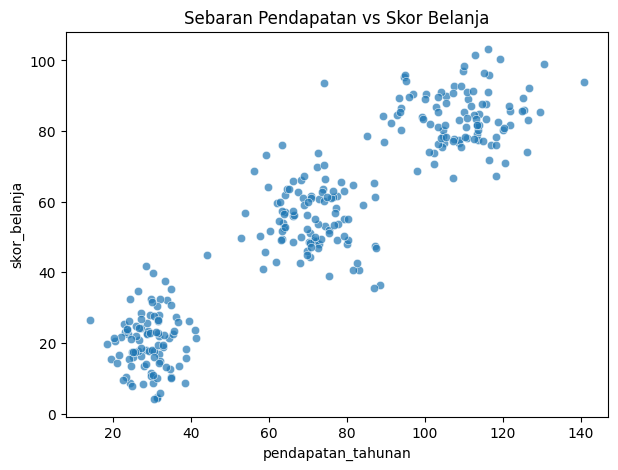

In [2]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x='pendapatan_tahunan',
    y='skor_belanja',
    alpha=0.7
)

plt.title("Sebaran Pendapatan vs Skor Belanja")
plt.show()

In [3]:
from sklearn.preprocessing import StandardScaler

X = df[['pendapatan_tahunan','skor_belanja']].values

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Rata-rata setelah scaling :", X_scaled.mean(axis=0).round(3))
print("Std setelah scaling :", X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling : [-0.  0.]
Std setelah scaling : [1. 1.]


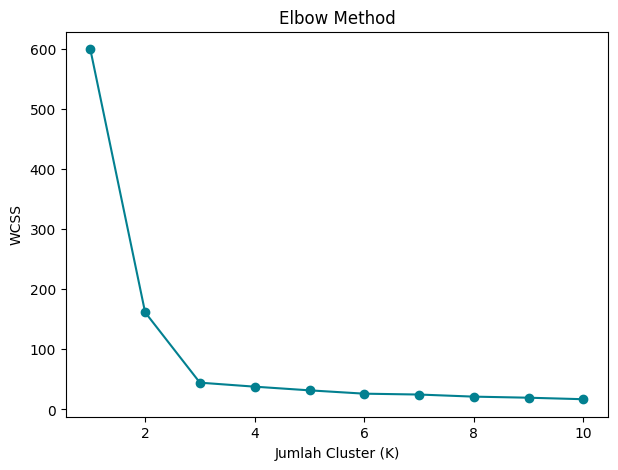

In [4]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1,11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        init='k-means++'
    )

    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(1,11), wcss, marker='o', color='#028090')

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [5]:
from sklearn.metrics import silhouette_score

model = KMeans(
    n_clusters=3,
    random_state=42,
    init='k-means++'
)

model.fit(X_scaled)

df['cluster'] = model.labels_

print("WCSS :", model.inertia_)
print("Silhouette Score :", silhouette_score(X_scaled, model.labels_))

print("\nRata-rata tiap cluster")
print(
    df.groupby("cluster")[["pendapatan_tahunan","skor_belanja"]]
    .mean()
    .round(2)
)

WCSS : 44.5564179805733
Silhouette Score : 0.6953274658286891

Rata-rata tiap cluster
         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.99         55.05
1                     29.31         20.27
2                    109.20         84.08


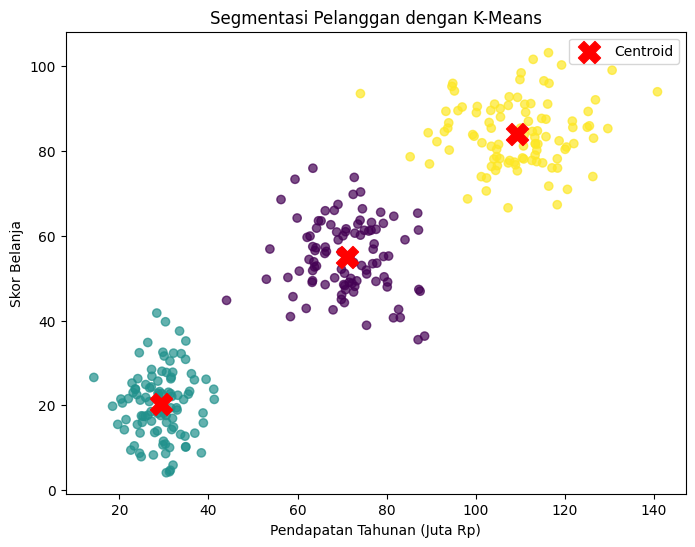

In [6]:
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(8,6))

plt.scatter(
    df["pendapatan_tahunan"],
    df["skor_belanja"],
    c=df["cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c="red",
    marker="X",
    s=250,
    label="Centroid"
)

plt.xlabel("Pendapatan Tahunan (Juta Rp)")
plt.ylabel("Skor Belanja")
plt.title("Segmentasi Pelanggan dengan K-Means")

plt.legend()
plt.show()

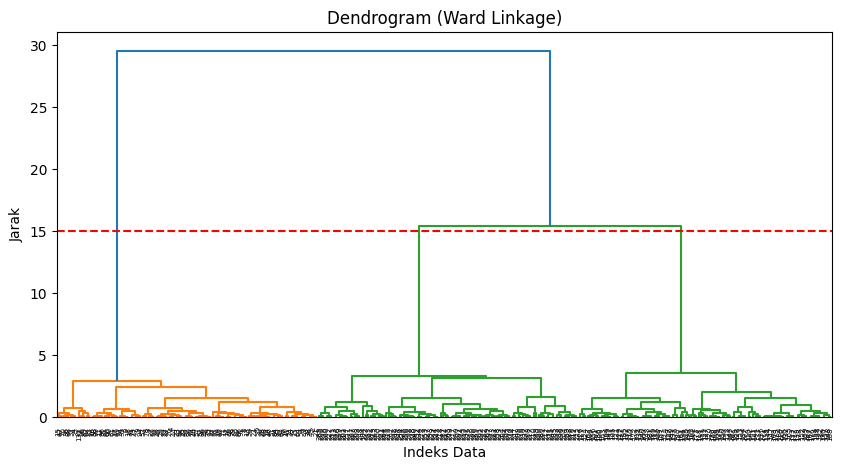

In [7]:
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(10,5))

dendrogram(Z)

plt.axhline(
    y=15,
    color="red",
    linestyle="--"
)

plt.title("Dendrogram (Ward Linkage)")
plt.xlabel("Indeks Data")
plt.ylabel("Jarak")

plt.show()

Kesimpulan

Berdasarkan hasil praktikum, dapat dipahami bahwa metode K-Means dapat digunakan untuk mengelompokkan data pelanggan berdasarkan kemiripan karakteristik, seperti pendapatan dan skor belanja. Penentuan jumlah cluster menggunakan Metode Elbow menunjukkan bahwa tiga cluster merupakan pilihan yang sesuai, dan hasil tersebut juga didukung oleh Hierarchical Clustering. Secara umum, teknik clustering membantu dalam mengenali pola pada data sehingga setiap kelompok pelanggan dapat dianalisis dengan lebih mudah sesuai karakteristiknya.